In [1]:
import os
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")
from config import *
from metric import *

## Compute Metrics

In [2]:
def parse_file_name(file_name):
    split_name = file_name.split('_')
    if file_name.startswith('internal_state'):
        layer = int(split_name[2][-2:])
        strong_model = split_name[3]
        weak_model = split_name[4]
        return {
            "strong": strong_model, 
            "weak": weak_model,
            "input": "internal state",
            "type": {16: "1/2", 20: "1/2", 21: "2/3", 27: "2/3", 24: "3/4", 30: "3/4"}[layer],
        }
    else:
        embedding_model = split_name[0]
        strong_model = split_name[1]
        weak_model = split_name[2]
        return {
            "strong": strong_model, 
            "weak": weak_model,
            "input": "prompt embedding",
            "type": embedding_model,
        }

def compute_metrics_for(prompt_type, is_code_gen=False):
    ro_results = list()
    cpt_50_results = list()
    cpt_80_results = list()
    benchmarks = CODE_GENERATION_BENCHMARKS if is_code_gen else TESTING_BENCHMARKS
    for benchmark in benchmarks:
        print(f'Now processing {benchmark}')
        bench_dir = f"../results/{benchmark.lower()}/preset/"
        for strong_model_name in STRONG_MODELS:
            for weak_model_name in WEAK_MODELS:
                for file in sorted(os.listdir(bench_dir)):
                    if not file.endswith(f'{prompt_type}.pkl') or strong_model_name not in file or weak_model_name not in file:
                        continue
                    result = parse_file_name(file)
                    result['benchmark'] = benchmark
                    df = pd.read_pickle(f"{bench_dir}/{file}")
                    ro_dict = compute_router_optimality(
                        benchmark=benchmark, 
                        strong_model_name=strong_model_name, 
                        weak_model_name=weak_model_name, 
                        strong_model_result_path=path_to_result_file_for(benchmark, strong_model_name),
                        weak_model_result_path=path_to_result_file_for(benchmark, weak_model_name),
                        probs_df=df)
                    ro_result = result.copy()
                    ro_result.update(ro_dict)
                    ro_results.append(ro_result)
                    
                    cpt_50_dict = compute_cpt(
                        benchmark=benchmark, 
                        strong_model_name=strong_model_name, 
                        weak_model_name=weak_model_name, 
                        strong_model_result_path=path_to_result_file_for(benchmark, strong_model_name),
                        weak_model_result_path=path_to_result_file_for(benchmark, weak_model_name),
                        probs_df=df,
                        target_pgr=0.5)
                    cpt_50_result = result.copy()
                    cpt_50_result.update(cpt_50_dict)
                    cpt_50_results.append(cpt_50_result)
                    
                    cpt_80_dict = compute_cpt(
                        benchmark=benchmark, 
                        strong_model_name=strong_model_name, 
                        weak_model_name=weak_model_name, 
                        strong_model_result_path=path_to_result_file_for(benchmark, strong_model_name),
                        weak_model_result_path=path_to_result_file_for(benchmark, weak_model_name),
                        probs_df=df,
                        target_pgr=0.8)
                    cpt_80_result = result.copy()
                    cpt_80_result.update(cpt_80_dict)
                    cpt_80_results.append(cpt_80_result)
    return ro_results, cpt_50_results, cpt_80_results

# Compute Router Optimality

In [3]:
# Config
prompt_type = DEFAULT_PROMPT_TYPE
internal_state_type = DEFAULT_INTERNAL_STATE_TYPE
embedding_type = DEFAULT_EMBEDDING_TYPE

In [4]:
ro_results, cpt_50_results, cpt_80_results = compute_metrics_for(prompt_type, is_code_gen=False)
df = pd.DataFrame(ro_results)
df.to_csv(f'metrics/router_optimality_{prompt_type}.csv')
df = pd.DataFrame(cpt_50_results)
df.to_csv(f'metrics/cpt_50_{prompt_type}.csv')
df = pd.DataFrame(cpt_80_results)
df.to_csv(f'metrics/cpt_80_{prompt_type}.csv')

ro_results, cpt_50_results, cpt_80_results = compute_metrics_for(prompt_type, is_code_gen=True)
df = pd.DataFrame(ro_results)
df.to_csv(f'metrics/router_optimality_{prompt_type}_codegen.csv')
df = pd.DataFrame(cpt_50_results)
df.to_csv(f'metrics/cpt_50_{prompt_type}_codegen.csv')
df = pd.DataFrame(cpt_80_results)
df.to_csv(f'metrics/cpt_80_{prompt_type}_codegen.csv')

Now processing TestEval_line
Now processing TestEval_branch
Now processing TestEval_path
Now processing TestEval_total
Now processing LIBRO_d4j
Now processing HumanEval
Now processing APPS


# Internal State vs. Prompt Embedding

In [5]:
def filter_by_input_type(df, internal_state_type, embedding_type):
    return df[(df['type'] == internal_state_type) | (df['type'] == embedding_type)]

def compute_and_print_statistics(testing_df, code_gen_df):
    rows = []
    
    for algorithm in ALGORITHMS:
        row_data = {'Algorithm': algorithm}
        
        ro_statistics = testing_df.groupby(['input'])[algorithm].agg(['mean', 'std'])
        internal_state_stats = ro_statistics.loc['internal state']
        prompt_embedding_stats = ro_statistics.loc['prompt embedding']
        
        row_data['Testing Internal State'] = f"{internal_state_stats['mean']:.3f} ({internal_state_stats['std']:.3f})"
        row_data['Testing Prompt Embedding'] = f"{prompt_embedding_stats['mean']:.3f} ({prompt_embedding_stats['std']:.3f})"
        
        ro_statistics = code_gen_df.groupby(['input'])[algorithm].agg(['mean', 'std'])
        internal_state_stats = ro_statistics.loc['internal state']
        prompt_embedding_stats = ro_statistics.loc['prompt embedding']
        
        row_data['Code Gen Internal State'] = f"{internal_state_stats['mean']:.3f} ({internal_state_stats['std']:.3f})"
        row_data['Code Gen Prompt Embedding'] = f"{prompt_embedding_stats['mean']:.3f} ({prompt_embedding_stats['std']:.3f})"
        
        rows.append(row_data)
    
    results_df = pd.DataFrame(rows)
    
    latex_output = results_df.to_latex(index=False, escape=False, column_format='lrrrr')
    print(latex_output)

def perform_paired_significance_test(df, dataset_name, the_higher_the_better=True):
    print(f"--- Statistical Test Results: {dataset_name} ---")
    print(f"{'Algorithm':<25} | {'Mean Diff':<10} | {'t-statistic':<12} | {'p-value':<12}")
    print("-" * 70)

    for alg in ALGORITHMS:
        grouped = df.groupby(['benchmark', 'strong', 'weak', 'input'])[alg].mean()
        paired_data = grouped.unstack(level='input')
        
        if 'internal state' not in paired_data.columns or 'prompt embedding' not in paired_data.columns:
            print(f"{alg:<25} | Insufficient data for pairing.")
            continue

        valid_pairs = paired_data.dropna(subset=['internal state', 'prompt embedding'])
        
        internal_scores = valid_pairs['internal state']
        embedding_scores = valid_pairs['prompt embedding']
        
        if the_higher_the_better:
            t_stat, p_val = stats.wilcoxon(internal_scores, embedding_scores, alternative='greater')
            mean_diff = (internal_scores - embedding_scores).mean()
        if not the_higher_the_better:
            t_stat, p_val = stats.wilcoxon(internal_scores, embedding_scores, alternative='less')
            mean_diff = (internal_scores - embedding_scores).mean()
        
        print(f"{alg:<25} | {mean_diff:+.4f}     | {t_stat:6.3f}       | {p_val:.6f}")
    print("\n")

In [ ]:
def calculate_wilcoxon_p(df, alg, the_higher_the_better=True):
    grouped = df.groupby(['benchmark', 'strong', 'weak', 'input'])[alg].mean()
    paired_data = grouped.unstack(level='input')

    if 'internal state' not in paired_data.columns or 'prompt embedding' not in paired_data.columns:
        return 1.0

    valid_pairs = paired_data.dropna(subset=['internal state', 'prompt embedding'])
    
    if valid_pairs.empty:
        return 1.0

    internal = valid_pairs['internal state']
    embedding = valid_pairs['prompt embedding']
    
    alt = 'greater' if the_higher_the_better else 'less'
    
    try:
        _, p_val = stats.wilcoxon(internal, embedding, alternative=alt, zero_method='zsplit')
        return p_val
    except ValueError:
        return 1.0

def compute_and_print_statistics_with_wilcoxon(testing_df, code_gen_df, the_higher_the_better=True):
    rows = []
    
    for algorithm in ALGORITHMS:
        row_data = {'Algorithm': algorithm}
        
        ro_statistics = testing_df.groupby(['input'])[algorithm].agg(['mean', 'std'])
        int_stats = ro_statistics.loc['internal state']
        emb_stats = ro_statistics.loc['prompt embedding']
        
        p_val_test = calculate_wilcoxon_p(testing_df, algorithm, the_higher_the_better)
        
        row_data['Testing Internal'] = f"{int_stats['mean']:.3f} ({int_stats['std']:.3f})"
        row_data['Testing Embedding'] = f"{emb_stats['mean']:.3f} ({emb_stats['std']:.3f})"
        row_data['Testing p-val'] = f"{p_val_test:.3f}" if p_val_test >= 0.001 else "$<$ 0.001"
        
        ro_statistics = code_gen_df.groupby(['input'])[algorithm].agg(['mean', 'std'])
        int_stats = ro_statistics.loc['internal state']
        emb_stats = ro_statistics.loc['prompt embedding']
        
        p_val_code = calculate_wilcoxon_p(code_gen_df, algorithm, the_higher_the_better)
        
        row_data['Code Gen Internal'] = f"{int_stats['mean']:.3f} ({int_stats['std']:.3f})"
        row_data['Code Gen Embedding'] = f"{emb_stats['mean']:.3f} ({emb_stats['std']:.3f})"
        row_data['Code Gen p-val'] = f"{p_val_code:.3f}" if p_val_code >= 0.001 else "$<$ 0.001"
        
        rows.append(row_data)
    
    results_df = pd.DataFrame(rows)
    
    latex_output = results_df.to_latex(index=False, escape=False, column_format='lrrrrrr')
    print(latex_output)

In [7]:
def plot_all_results(testing_df, code_gen_df, algorithms):
    plt.rcParams.update({'font.size': 14})
    
    df_test = testing_df.copy()
    df_test['Benchmark Type'] = 'Testing'
    df_code = code_gen_df.copy()
    df_code['Benchmark Type'] = 'Code\nGeneration'
    full_df = pd.concat([df_test, df_code], ignore_index=True)
    full_df['input'] = full_df['input'].replace({
        'internal state': 'Internal State', 
        'prompt embedding': 'Prompt Embedding'
    })
    full_df = full_df.rename(columns={'input': 'Input'})

    fig, axes = plt.subplots(1, len(algorithms), figsize=(4 * len(algorithms), 6), sharey=True)
    
    global_max_val = full_df[algorithms].max().max()
    h_global = global_max_val * 0.05 

    for idx, alg in enumerate(algorithms):
        ax = axes[idx]
        sns.boxplot(data=full_df, x='Benchmark Type', y=alg, hue='Input', 
                    palette='Set2', ax=ax, order=['Testing', 'Code\nGeneration'], 
                    hue_order=['Internal State', 'Prompt Embedding'])
        
        ax.set_title(alg, fontsize=16)
        ax.set_xlabel('')
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        ax.set_axisbelow(True)
        
        if idx == 0:
            ax.set_ylabel('Router Optimality', fontsize=15)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', left=False, labelleft=False)

        if idx < len(algorithms) - 1:
            if ax.get_legend(): ax.get_legend().remove()
        else:
            sns.move_legend(ax, "best", fontsize=11)

        p_val_test = calculate_wilcoxon_p(testing_df, alg)
        y_max_test = testing_df[alg].max()
        
        y_line_test = y_max_test + h_global * 0.5
        
        x1, x2 = -0.2, 0.2
        ax.plot([x1, x1, x2, x2], [y_line_test, y_line_test+h_global*0.2, y_line_test+h_global*0.2, y_line_test], lw=1.5, c='k')
        p_text_test = f"p={p_val_test:.3f}" if p_val_test >= 0.001 else "p < 0.001"
        ax.text((x1+x2)*0.5, y_line_test+h_global*0.3, p_text_test, ha='center', va='bottom', color='k', fontsize=12)

        p_val_code = calculate_wilcoxon_p(code_gen_df, alg)
        y_max_code = code_gen_df[alg].max()
        
        y_line_code = y_max_code + h_global * 0.5
        
        x1, x2 = 0.8, 1.2
        ax.plot([x1, x1, x2, x2], [y_line_code, y_line_code+h_global*0.2, y_line_code+h_global*0.2, y_line_code], lw=1.5, c='k')
        p_text_code = f"p={p_val_code:.3f}" if p_val_code >= 0.001 else "p < 0.001"
        ax.text((x1+x2)*0.5, y_line_code+h_global*0.3, p_text_code, ha='center', va='bottom', color='k', fontsize=12)
        
    axes[0].set_ylim(top=global_max_val + h_global * 2)

    plt.tight_layout()
    plt.savefig('figures/RQ1_ro_comparison.pdf')
    plt.close()

In [8]:
def plot_per_model_pair(testing_df, code_gen_df, algorithms):
    plt.rcParams.update({'font.size': 14})
    
    unique_weak_models = sorted(WEAK_MODELS)
    weak_model_map = {name: chr(65 + i) for i, name in enumerate(unique_weak_models)}
    
    print("--- Figure Caption Mapping ---")
    for name, code in weak_model_map.items():
        print(f"{code}: {name}")
    print("------------------------------")

    def process_df(df):
        d = df.copy()
        d = d.sort_values(by=['strong', 'weak'])
        d['model pair'] = d['strong'] + "_" + d['weak']
        d['Weak Label'] = d['weak'].map(weak_model_map)
        d['input'] = d['input'].replace({
            'internal state': 'Internal State', 
            'prompt embedding': 'Prompt Embedding'
        })
        d = d.rename(columns={'input': 'Input'})
        return d

    def update_xticklabels(ax, row_index):
        if row_index != len(algorithms) - 1:
            ax.set_xticklabels([])
            return
        encoded_labels = list()
        for label in ax.get_xticklabels():
            model_pair = label.get_text()
            weak_model = model_pair.split('_')[1]
            encoded_labels.append(weak_model_map[weak_model])
        ax.set_xticklabels(encoded_labels)

    df_test = process_df(testing_df)
    df_code = process_df(code_gen_df)

    fig, axes = plt.subplots(len(algorithms), 2, figsize=(20, 15), sharey=True, gridspec_kw={'wspace': 0.05})

    palette = 'Set2'
    hue_order = ['Internal State', 'Prompt Embedding']

    for i, alg in enumerate(algorithms):
        # --- Plot 1: Testing ---
        ax = axes[i][0]
        if i == 0:
            ax.set_title('Testing', fontsize=16, pad=15)
        else: 
            ax.set_title('')

        sns.barplot(data=df_test, x='model pair', y=alg, hue='Input', 
                    palette=palette, ax=ax, hue_order=hue_order)
        sns.stripplot(data=df_test, x='model pair', y=alg, hue='Input', 
                    palette='dark:black', ax=ax, hue_order=hue_order,
                    dodge=True, jitter=False, size=5, marker="D", alpha=0.6, legend=False)
        
        if i == len(algorithms) - 1:
            ax.set_xlabel('Weak Models')
        else:
            ax.set_xlabel('')
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        ax.set_axisbelow(True)
        
        if i == len(algorithms) // 2:
            ax.set_ylabel('Router Optimality', fontsize=15)
        else:
            ax.set_ylabel('')
        update_xticklabels(ax, i)
        if ax.get_legend(): ax.get_legend().remove()

        # --- Plot 2: Code Generation ---
        ax = axes[i][1]

        if i == 0:
            ax.set_title('Code Generation', fontsize=16, pad=15)
        else: 
            ax.set_title('')
        sns.barplot(data=df_code, x='model pair', y=alg, hue='Input', 
                    palette=palette, ax=ax, hue_order=hue_order)
        sns.stripplot(data=df_code, x='model pair', y=alg, hue='Input', 
                    palette='dark:black', ax=ax, hue_order=hue_order,
                    dodge=True, jitter=False, size=5, marker="D", alpha=0.6, legend=False)
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        ax.set_axisbelow(True)
        ax.set_ylabel('')
        ax.tick_params(axis='y', left=False, labelleft=False)
        update_xticklabels(ax, i)
        if i == len(algorithms) - 1:
            ax.set_xlabel('Weak Models')
        else:
            ax.set_xlabel('')
        if i == len(algorithms) - 1:
            sns.move_legend(ax, "lower left", fontsize=11, title="Input")
        else:
            if ax.get_legend(): ax.get_legend().remove()
        
        if i == 0:
            alg = 'LR'
        axes[i][1].text(1.02, 0.5, alg, transform=axes[i][1].transAxes, rotation=270, va='center', ha='left', fontsize=14)
       
        for ax in axes[i]:
            ax.set_ylim(0.3, 1.0)
            y_min, y_max = ax.get_ylim()
            
            n_weak = len(unique_weak_models)
            ax.margins(x=0)
            if i == 0:
                for strong_model_index, strong_model in enumerate(STRONG_MODELS):
                    center_x = (strong_model_index * n_weak) + (n_weak - 1) / 2           
                    ax.text(center_x, y_max * 0.96, strong_model, ha='center', va='top', fontsize=14)
                
            divider_x = n_weak - 0.5
            ax.axvline(x=divider_x, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

    plt.tight_layout()
    plt.savefig(f'figures/RQ1_ro_per_model_pair_comparison.pdf', bbox_inches='tight')
    plt.show()
    plt.close()

## RQ1-1 Router Optimality

For clarity, only adopt the best performing option for each input
- **Internal state** extracted from the **3/4-th layer**
- **Prompt Embedding** embedded by **text-embedding-3-large**

In [9]:
testing_df = filter_by_input_type(pd.read_csv(f'metrics/router_optimality_{prompt_type}.csv', index_col=0), internal_state_type, embedding_type)
code_gen_df = filter_by_input_type(pd.read_csv(f'metrics/router_optimality_{prompt_type}_codegen.csv', index_col=0), internal_state_type, embedding_type)

In [10]:
compute_and_print_statistics_with_wilcoxon(testing_df, code_gen_df)

\begin{tabular}{lrrrrrr}
\toprule
Algorithm & Testing Internal & Testing Embedding & Testing p-val & Code Gen Internal & Code Gen Embedding & Code Gen p-val \\
\midrule
Logistic Regression & 0.539 (0.055) & 0.522 (0.042) & 0.011 & 0.674 (0.134) & 0.608 (0.107) & $<$ 0.001 \\
SVM & 0.514 (0.055) & 0.501 (0.040) & 0.010 & 0.657 (0.150) & 0.609 (0.101) & 0.010 \\
MLP & 0.537 (0.046) & 0.531 (0.050) & 0.034 & 0.652 (0.093) & 0.623 (0.073) & 0.035 \\
Ensemble & 0.535 (0.056) & 0.527 (0.045) & 0.033 & 0.683 (0.127) & 0.631 (0.100) & 0.001 \\
RouteLLM & 0.533 (0.051) & 0.524 (0.039) & 0.150 & 0.654 (0.100) & 0.625 (0.069) & 0.013 \\
\bottomrule
\end{tabular}



In [11]:
perform_paired_significance_test(testing_df, "Testing")
perform_paired_significance_test(code_gen_df, "Code Generation")

--- Statistical Test Results: Testing ---
Algorithm                 | Mean Diff  | t-statistic  | p-value     
----------------------------------------------------------------------
Logistic Regression       | +0.0173     | 873.000       | 0.011189
SVM                       | +0.0123     | 879.000       | 0.009534
MLP                       | +0.0066     | 827.000       | 0.033902
Ensemble                  | +0.0081     | 828.000       | 0.033166
RouteLLM                  | +0.0085     | 746.000       | 0.149977


--- Statistical Test Results: Code Generation ---
Algorithm                 | Mean Diff  | t-statistic  | p-value     
----------------------------------------------------------------------
Logistic Regression       | +0.0657     | 208.000       | 0.000003
SVM                       | +0.0479     | 167.000       | 0.009617
MLP                       | +0.0291     | 154.000       | 0.034790
Ensemble                  | +0.0522     | 182.000       | 0.001356
RouteLLM               

In [12]:
plot_all_results(testing_df, code_gen_df, ALGORITHMS)

--- Figure Caption Mapping ---
A: llama3-8b
B: llama3.1-8b
C: mistral-nemo-12b
D: phi4-14b
E: qwen2.5-coder-7b
------------------------------


/var/folders/cy/pnx3rqp534d0ghwqtxn7lb2w0000gn/T/ipykernel_11581/1826376126.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(encoded_labels)
/var/folders/cy/pnx3rqp534d0ghwqtxn7lb2w0000gn/T/ipykernel_11581/1826376126.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(encoded_labels)
/var/folders/cy/pnx3rqp534d0ghwqtxn7lb2w0000gn/T/ipykernel_11581/1826376126.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


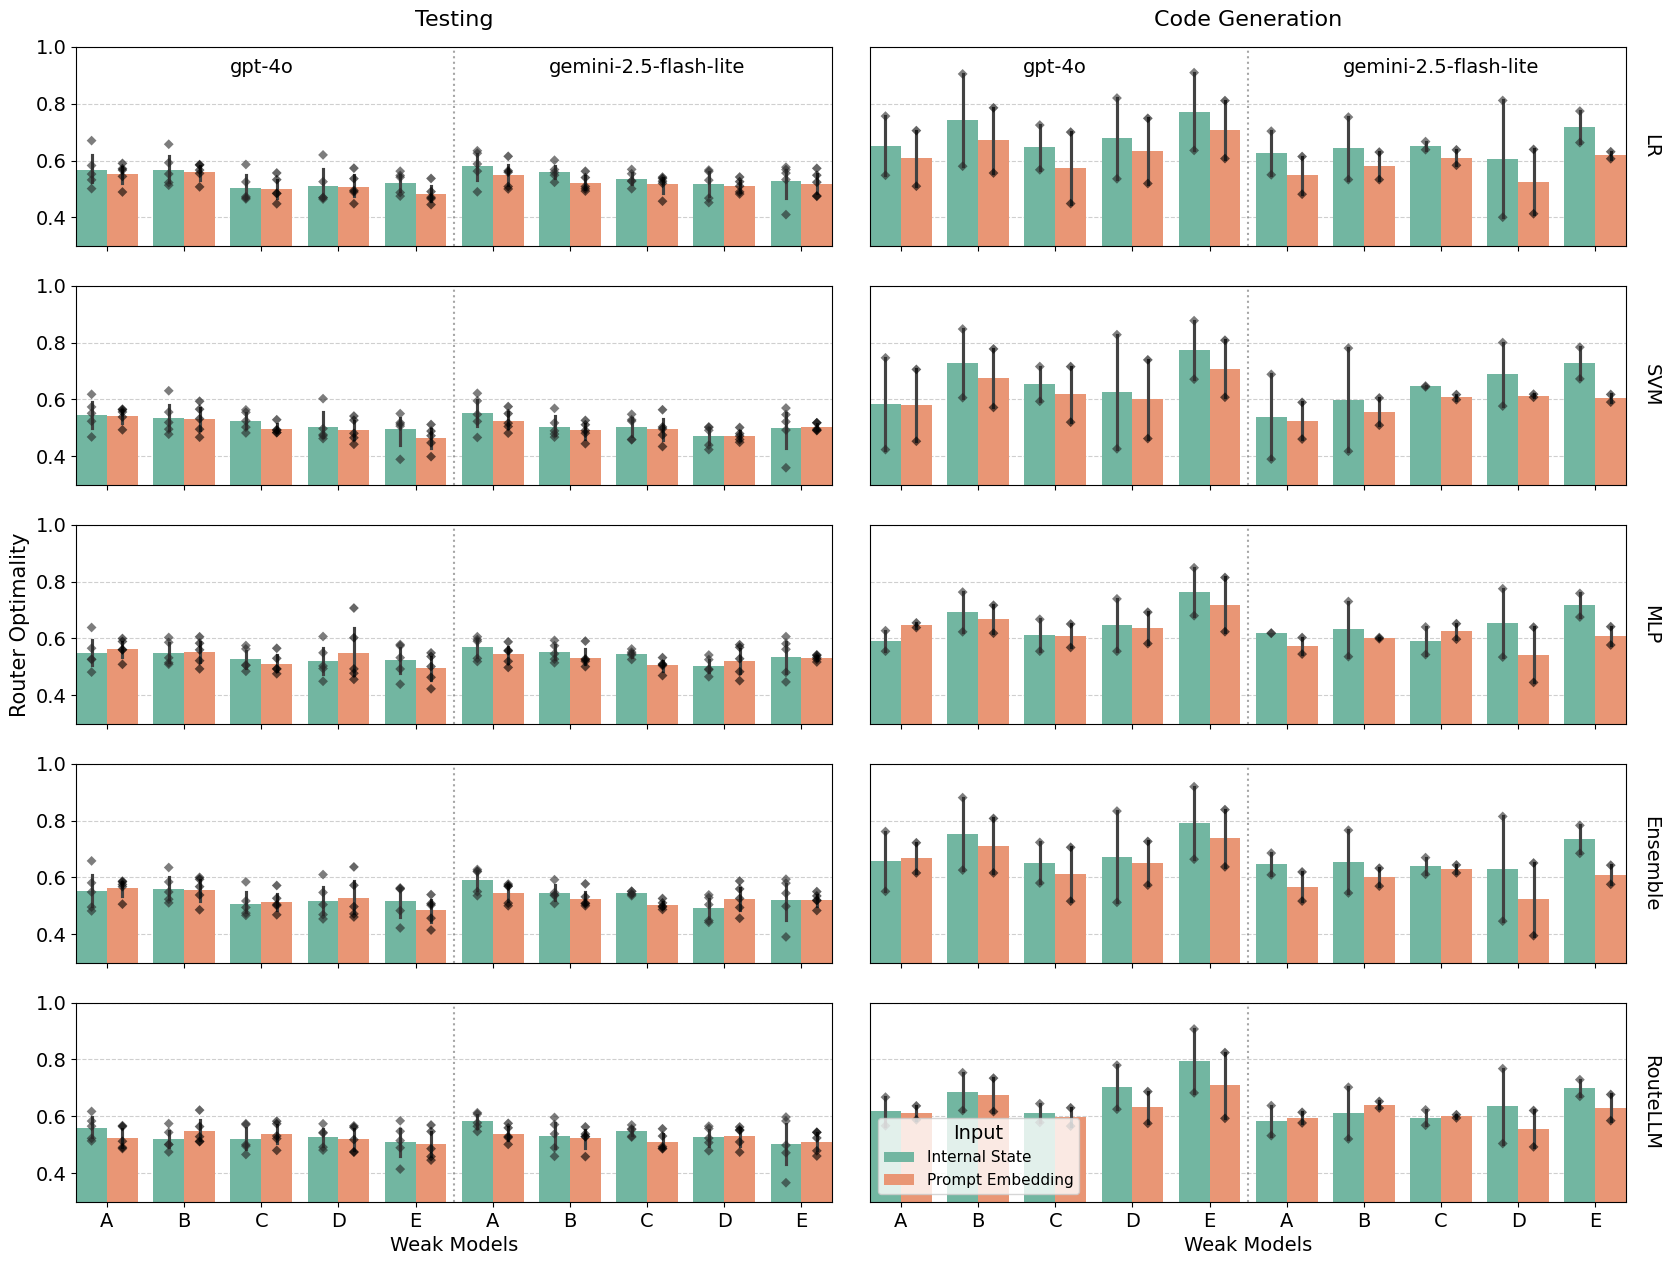

In [13]:
plot_per_model_pair(testing_df, code_gen_df, ALGORITHMS)

## RQ1-2 Cost-Performance Trade-off

### Call-Performance Threshold (50%)

In [14]:
testing_df = filter_by_input_type(pd.read_csv(f'metrics/cpt_50_{prompt_type}.csv', index_col=0), internal_state_type, embedding_type)
code_gen_df = filter_by_input_type(pd.read_csv(f'metrics/cpt_50_{prompt_type}_codegen.csv', index_col=0), internal_state_type, embedding_type)

In [15]:
testing_df[testing_df['Logistic Regression'] == -1.0]

,strong,weak,input,type,benchmark,Logistic Regression,SVM,MLP,Ensemble,RouteLLM
146,gpt-4o,phi4-14b,internal state,3/4,TestEval_path,-1.0,-1.0,-1.0,-1.0,-1.0
148,gpt-4o,phi4-14b,prompt embedding,text-embedding-3-large,TestEval_path,-1.0,-1.0,-1.0,-1.0,-1.0


In [16]:
code_gen_df[code_gen_df['Logistic Regression'] == -1.0]

,strong,weak,input,type,benchmark,Logistic Regression,SVM,MLP,Ensemble,RouteLLM


In [17]:
compute_and_print_statistics(testing_df[testing_df['Logistic Regression'] != -1.0], code_gen_df) # Exclude samples that weak model outperformed strong model

\begin{tabular}{lrrrr}
\toprule
Algorithm & Testing Internal State & Testing Prompt Embedding & Code Gen Internal State & Code Gen Prompt Embedding \\
\midrule
Logistic Regression & 0.410 (0.109) & 0.456 (0.112) & 0.323 (0.185) & 0.363 (0.167) \\
SVM & 0.482 (0.118) & 0.490 (0.132) & 0.318 (0.186) & 0.359 (0.170) \\
MLP & 0.436 (0.123) & 0.439 (0.116) & 0.306 (0.149) & 0.344 (0.137) \\
Ensemble & 0.417 (0.119) & 0.445 (0.122) & 0.308 (0.164) & 0.344 (0.153) \\
RouteLLM & 0.438 (0.102) & 0.442 (0.116) & 0.306 (0.153) & 0.336 (0.137) \\
\bottomrule
\end{tabular}



In [18]:
perform_paired_significance_test(testing_df[testing_df['Logistic Regression'] != -1.0], "Testing", the_higher_the_better=False)
perform_paired_significance_test(code_gen_df, "Code Generation", the_higher_the_better=False)

--- Statistical Test Results: Testing ---
Algorithm                 | Mean Diff  | t-statistic  | p-value     
----------------------------------------------------------------------
Logistic Regression       | -0.0459     | 306.000       | 0.003164
SVM                       | -0.0081     | 467.000       | 0.075186
MLP                       | -0.0026     | 424.000       | 0.046275
Ensemble                  | -0.0276     | 392.000       | 0.034368
RouteLLM                  | -0.0040     | 504.500       | 0.264461


--- Statistical Test Results: Code Generation ---
Algorithm                 | Mean Diff  | t-statistic  | p-value     
----------------------------------------------------------------------
Logistic Regression       | -0.0395     | 34.500       | 0.013155
SVM                       | -0.0409     | 38.000       | 0.010848
MLP                       | -0.0379     | 42.500       | 0.017303
Ensemble                  | -0.0356     | 38.000       | 0.010894
RouteLLM                  |

### Call-Performance Threshold (80%)

In [19]:
testing_df = filter_by_input_type(pd.read_csv(f'metrics/cpt_80_{prompt_type}.csv', index_col=0), internal_state_type, embedding_type)
code_gen_df = filter_by_input_type(pd.read_csv(f'metrics/cpt_80_{prompt_type}_codegen.csv', index_col=0), internal_state_type, embedding_type)

In [20]:
testing_df[testing_df['Logistic Regression'] == -1.0]

,strong,weak,input,type,benchmark,Logistic Regression,SVM,MLP,Ensemble,RouteLLM
146,gpt-4o,phi4-14b,internal state,3/4,TestEval_path,-1.0,-1.0,-1.0,-1.0,-1.0
148,gpt-4o,phi4-14b,prompt embedding,text-embedding-3-large,TestEval_path,-1.0,-1.0,-1.0,-1.0,-1.0


In [21]:
code_gen_df[code_gen_df['Logistic Regression'] == -1.0]

,strong,weak,input,type,benchmark,Logistic Regression,SVM,MLP,Ensemble,RouteLLM


In [22]:
compute_and_print_statistics(testing_df[testing_df['Logistic Regression'] != -1.0], code_gen_df) # Exclude samples that weak model outperformed strong model

\begin{tabular}{lrrrr}
\toprule
Algorithm & Testing Internal State & Testing Prompt Embedding & Code Gen Internal State & Code Gen Prompt Embedding \\
\midrule
Logistic Regression & 0.734 (0.118) & 0.763 (0.099) & 0.549 (0.266) & 0.630 (0.245) \\
SVM & 0.777 (0.081) & 0.797 (0.132) & 0.559 (0.276) & 0.617 (0.248) \\
MLP & 0.731 (0.134) & 0.727 (0.160) & 0.586 (0.261) & 0.622 (0.199) \\
Ensemble & 0.727 (0.138) & 0.734 (0.139) & 0.550 (0.265) & 0.602 (0.230) \\
RouteLLM & 0.724 (0.131) & 0.721 (0.158) & 0.572 (0.241) & 0.618 (0.217) \\
\bottomrule
\end{tabular}



In [23]:
perform_paired_significance_test(testing_df[testing_df['Logistic Regression'] != -1.0], "Testing", the_higher_the_better=False)
perform_paired_significance_test(code_gen_df, "Code Generation", the_higher_the_better=False)

--- Statistical Test Results: Testing ---
Algorithm                 | Mean Diff  | t-statistic  | p-value     
----------------------------------------------------------------------
Logistic Regression       | -0.0294     | 370.500       | 0.048521
SVM                       | -0.0200     | 353.500       | 0.012953
MLP                       | +0.0034     | 396.500       | 0.057825
Ensemble                  | -0.0067     | 451.500       | 0.116921
RouteLLM                  | +0.0027     | 534.000       | 0.289836


--- Statistical Test Results: Code Generation ---
Algorithm                 | Mean Diff  | t-statistic  | p-value     
----------------------------------------------------------------------
Logistic Regression       | -0.0808     |  1.500       | 0.000084
SVM                       | -0.0571     | 53.500       | 0.026585
MLP                       | -0.0366     | 69.000       | 0.094674
Ensemble                  | -0.0526     | 46.000       | 0.013321
RouteLLM                  |